## 1 · Setup

In [1]:
import importlib, subprocess, sys

REQUIRED = {
    "transformers":  "transformers>=4.41,<5",
    "datasets":      "datasets>=2.18",
    "accelerate":    "accelerate>=0.27",
    "sentencepiece": "sentencepiece",
    "tokenizers":    "tokenizers",
    "torch":         "torch",
    "sklearn":       "scikit-learn",
    "pandas":        "pandas",
    "numpy":         "numpy",
    "matplotlib":    "matplotlib",
    "seaborn":       "seaborn",
    "gensim":        "gensim",
    "emoji":         "emoji",
    "tqdm":          "tqdm",
    "pyarrow":       "pyarrow",
}

missing = []
for mod, spec in REQUIRED.items():
    try:
        importlib.import_module(mod)
    except Exception:
        missing.append(spec)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependencies OK.")


Dependencies OK.


## 2 · Imports

In [2]:
import os, re, json, math, random, gc, time, warnings
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve,
)
from sklearn.manifold import TSNE

import emoji as emoji_lib

import transformers
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForMaskedLM, AutoModelForSequenceClassification,
    DataCollatorForLanguageModeling, DataCollatorWithPadding,
    Trainer, TrainingArguments, EarlyStoppingCallback, set_seed,
)
from datasets import Dataset as HFDataset, DatasetDict

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.dpi"] = 110

print("Transformers:", transformers.__version__)
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "| device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    print("WARNING: No GPU detected. Training will be very slow. "
          "In Colab go to Runtime → Change runtime type → T4 GPU.")



Transformers: 4.40.1
Torch: 2.2.2+cpu | CUDA: False | device: cpu


## 3 · Configuration block (all hyperparameters live here)

In [3]:
# Auto-detect environment (Colab vs local)
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    PROJECT_ROOT = Path("/content")
except ImportError:
    IN_COLAB = False
    PROJECT_ROOT = Path.cwd()
print("Project root:", PROJECT_ROOT, "| In Colab:", IN_COLAB)


@dataclass
class CFG:
    # paths (all relative to PROJECT_ROOT)
    csv_name: str    = "political_reddit_100k.csv"
    splits_dir: str  = "splits"
    models_dir: str  = "models"
    results_dir: str = "results"
    figures_dir: str = "figures"
    tables_dir: str  = "tables"
    cache_dir: str   = "cache"

    # data
    text_col: str  = "text"
    label_col: str = "label"
    seed_split: int = 42

    # model
    base_model: str  = "microsoft/deberta-v3-base"
    max_seq_len: int = 128

    # TAPT
    tapt_epochs: int      = 3
    tapt_lr: float        = 5e-5
    tapt_bs: int          = 32
    tapt_grad_accum: int  = 1
    tapt_warmup_ratio: float = 0.06
    mlm_probability: float   = 0.15

    # Fine-tune
    ft_epochs: int        = 3
    ft_lr_base: float     = 2e-5     # base-size tolerates slightly higher LR than large
    ft_lr_head: float     = 1e-4
    llrd_factor: float    = 0.95
    ft_warmup_ratio: float = 0.06
    ft_bs: int            = 32
    ft_grad_accum: int    = 1
    label_smoothing: float = 0.05
    weight_decay: float   = 0.01
    grad_clip: float      = 1.0

    # FGM
    fgm_epsilon: float = 1.0
    fgm_emb_name: str  = "deberta.embeddings.word_embeddings"

    # multi-seed: default single seed. Flip MULTI_SEED to enable 3-seed run.
    seeds: Tuple[int, ...] = (42,)

    # eval
    eval_bs: int = 64

    # auto-set in next cell
    bf16: bool = False
    fp16: bool = False

# ── Flag: set to True to enable multi-seed (42, 13, 2024) on E3 ──
MULTI_SEED = False

cfg = CFG()
if MULTI_SEED:
    cfg.seeds = (42, 13, 2024)

# Resolve CSV path (Colab Files tab or local cwd)
csv_candidates = [
    PROJECT_ROOT / cfg.csv_name,
    Path.cwd() / cfg.csv_name,
    Path("/content") / cfg.csv_name,
]
CSV_PATH = next((p for p in csv_candidates if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        f"Could not find '{cfg.csv_name}'. Looked in:\n  "
        + "\n  ".join(str(p) for p in csv_candidates)
        + "\nIn Colab: drag the file into the Files panel (it lands in /content/)."
    )
print("CSV path:", CSV_PATH)

# Create output dirs
ROOT = PROJECT_ROOT
for d in [cfg.splits_dir, cfg.models_dir, cfg.results_dir,
          cfg.figures_dir, cfg.tables_dir, cfg.cache_dir]:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

print(json.dumps({k: str(v) for k, v in asdict(cfg).items()}, indent=2))


Project root: d:\PROJECTS\NLP - PROJECT | In Colab: False
CSV path: d:\PROJECTS\NLP - PROJECT\political_reddit_100k.csv
{
  "csv_name": "political_reddit_100k.csv",
  "splits_dir": "splits",
  "models_dir": "models",
  "results_dir": "results",
  "figures_dir": "figures",
  "tables_dir": "tables",
  "cache_dir": "cache",
  "text_col": "text",
  "label_col": "label",
  "seed_split": "42",
  "base_model": "microsoft/deberta-v3-base",
  "max_seq_len": "128",
  "tapt_epochs": "3",
  "tapt_lr": "5e-05",
  "tapt_bs": "32",
  "tapt_grad_accum": "1",
  "tapt_warmup_ratio": "0.06",
  "mlm_probability": "0.15",
  "ft_epochs": "3",
  "ft_lr_base": "2e-05",
  "ft_lr_head": "0.0001",
  "llrd_factor": "0.95",
  "ft_warmup_ratio": "0.06",
  "ft_bs": "32",
  "ft_grad_accum": "1",
  "label_smoothing": "0.05",
  "weight_decay": "0.01",
  "grad_clip": "1.0",
  "fgm_epsilon": "1.0",
  "fgm_emb_name": "deberta.embeddings.word_embeddings",
  "seeds": "(42,)",
  "eval_bs": "64",
  "bf16": "False",
  "fp16": 

## 4 · Reproducibility + mixed-precision auto-detect

In [4]:
def set_global_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    set_seed(seed)

set_global_seed(cfg.seed_split)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Robust BF16/FP16 detection — fall back gracefully
def detect_precision():
    if not torch.cuda.is_available():
        return False, False
    try:
        cap_major = torch.cuda.get_device_capability(0)[0]
        if cap_major >= 8:
            # smoke-test BF16
            x = torch.zeros(2, dtype=torch.bfloat16, device="cuda")
            del x
            return True, False
    except Exception:
        pass
    try:
        x = torch.zeros(2, dtype=torch.float16, device="cuda")
        del x
        return False, True
    except Exception:
        return False, False

cfg.bf16, cfg.fp16 = detect_precision()
print(f"Precision → bf16={cfg.bf16} fp16={cfg.fp16}")
print("Device:", DEVICE)


Precision → bf16=False fp16=False
Device: cpu


## 5 · Data loading

In [5]:
df = pd.read_csv(CSV_PATH)
print("Loaded:", df.shape)
df.head(3)


Loaded: (100000, 2)


,text,label
0,Do you consider CNN to be?,1
1,Where did the liberal touch you? \n\nShow me ...,1
2,We do need to apologize for some things. The ...,0


## 6 · Integrity checks

In [6]:
assert cfg.text_col in df.columns and cfg.label_col in df.columns, "Missing columns."
df[cfg.label_col] = df[cfg.label_col].astype(int)
df[cfg.text_col]  = df[cfg.text_col].astype(str)

n_null  = df[cfg.text_col].isna().sum()
n_empty = (df[cfg.text_col].str.strip() == "").sum()
n_dup   = df.duplicated(subset=[cfg.text_col]).sum()
print(f"rows={len(df)}  nulls={n_null}  empty={n_empty}  dup_text={n_dup}")
print("\nLabel counts:\n", df[cfg.label_col].value_counts().sort_index())
assert set(df[cfg.label_col].unique()) == {0, 1}, "Labels must be {0, 1}"


rows=100000  nulls=0  empty=0  dup_text=3307

Label counts:
 label
0    50000
1    50000
Name: count, dtype: int64


## 7 · Compact EDA

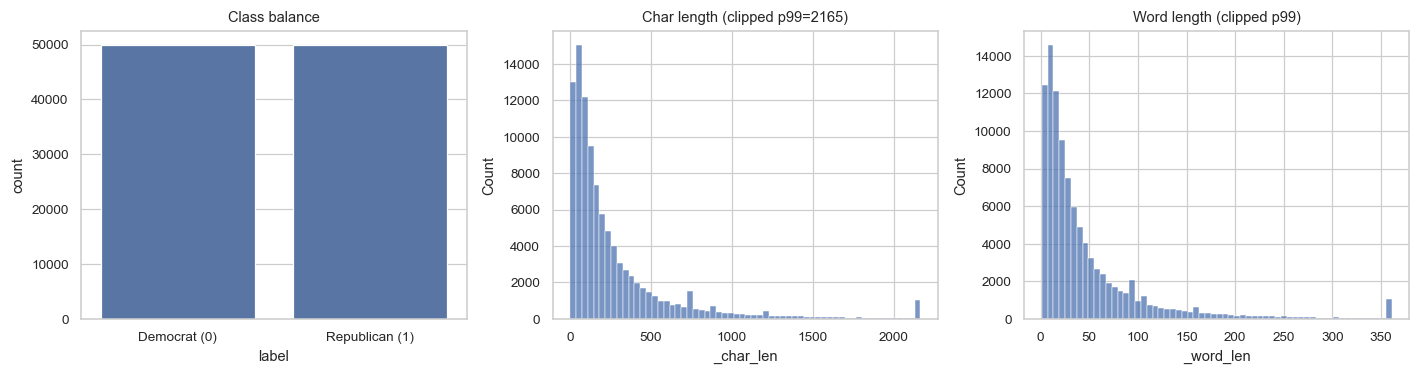

,n,char_len_p50,char_len_p95,word_len_p50,word_len_p95
label,,,,,
0,50000,132.0,911.0,23.0,153.0
1,50000,167.0,1095.0,29.0,175.0


In [7]:
df["_char_len"] = df[cfg.text_col].str.len()
df["_word_len"] = df[cfg.text_col].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
sns.countplot(x=cfg.label_col, data=df, ax=axes[0])
axes[0].set_title("Class balance")
axes[0].set_xticklabels(["Democrat (0)", "Republican (1)"])

clip = df["_char_len"].quantile(0.99)
sns.histplot(df["_char_len"].clip(upper=clip), bins=60, ax=axes[1])
axes[1].set_title(f"Char length (clipped p99={int(clip)})")

sns.histplot(df["_word_len"].clip(upper=df["_word_len"].quantile(0.99)),
             bins=60, ax=axes[2])
axes[2].set_title("Word length (clipped p99)")
plt.tight_layout()
plt.savefig(ROOT / cfg.figures_dir / "eda_overview.png", bbox_inches="tight")
plt.show()

summary = pd.DataFrame({
    "n":              df.groupby(cfg.label_col).size(),
    "char_len_p50":   df.groupby(cfg.label_col)["_char_len"].median().round(1),
    "char_len_p95":   df.groupby(cfg.label_col)["_char_len"].quantile(0.95).round(1),
    "word_len_p50":   df.groupby(cfg.label_col)["_word_len"].median().round(1),
    "word_len_p95":   df.groupby(cfg.label_col)["_word_len"].quantile(0.95).round(1),
})
display(summary)
df = df.drop(columns=["_char_len", "_word_len"])


## 8 · Preprocessing (anti-leakage)

Scrubs subreddit name leaks, mod-bot residue, URLs, user mentions, markdown noise. Demojizes emoji.


In [8]:
_URL_RE   = re.compile(r"https?://\S+|www\.\S+")
_USER_RE  = re.compile(r"/u/[A-Za-z0-9_\-]+|\bu/[A-Za-z0-9_\-]+")
_SUB_RE   = re.compile(r"/r/[A-Za-z0-9_\-]+|\br/[A-Za-z0-9_\-]+")
_BOT_RE   = re.compile(
    r"(?is)(i\s*am\s*a\s*bot[^.\n]*[.\n]?|automoderator|^/?_{2,}.*$)", re.MULTILINE)
_MD_BOLD  = re.compile(r"\*{1,3}|_{2,}")
_QUOTE_LN = re.compile(r"^\s*>\s?", re.MULTILINE)
_WS_RE    = re.compile(r"\s+")
_CHARREP  = re.compile(r"(.)\1{2,}")

def preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text
    t = _BOT_RE.sub(" ", t)
    t = _URL_RE.sub(" [URL] ", t)
    t = _SUB_RE.sub(" [SUBREDDIT] ", t)        # anti-leakage
    t = _USER_RE.sub(" [USER] ", t)
    t = _QUOTE_LN.sub("", t)
    t = _MD_BOLD.sub("", t)
    t = _CHARREP.sub(r"\1\1", t)
    t = emoji_lib.demojize(t, delimiters=(" :", ": "))
    t = _WS_RE.sub(" ", t).strip()
    return t

# Sanity check
for s in [
    "I support /r/democrats — see https://example.com by /u/foo",
    "MAGA!!! Sooooo proud, check /r/Republicans  👍",
    "I am a bot. This action was performed automatically.",
]:
    print(repr(s), "→", repr(preprocess(s)))

# Apply + cache
cache_path = ROOT / cfg.cache_dir / "preprocessed.parquet"
if cache_path.exists():
    df_pp = pd.read_parquet(cache_path)
    print("Loaded cached preprocessed:", df_pp.shape)
else:
    tqdm.pandas(desc="preprocess")
    df_pp = df.copy()
    df_pp["text"] = df_pp[cfg.text_col].progress_apply(preprocess)
    keep = df_pp["text"].str.len() > 0
    print(f"Dropping {(~keep).sum()} rows that became empty after preprocessing")
    df_pp = df_pp[keep].reset_index(drop=True)[["text", cfg.label_col]]
    df_pp.to_parquet(cache_path, index=False)

print(df_pp.head(3))


'I support /r/democrats — see https://example.com by /u/foo' → 'I support [SUBREDDIT] — see [URL] by [USER]'
'MAGA!!! Sooooo proud, check /r/Republicans  👍' → 'MAGA!! Soo proud, check [SUBREDDIT] :thumbs_up:'
'I am a bot. This action was performed automatically.' → 'This action was performed automatically.'


preprocess:   0%|          | 0/100000 [00:00<?, ?it/s]

Dropping 0 rows that became empty after preprocessing
                                                text  label
0                         Do you consider CNN to be?      1
1  Where did the liberal touch you? Show me on th...      1
2  We do need to apologize for some things. The f...      0


## 9 · Stratified 80 / 10 / 10 split (persisted; LOCKED)

In [ ]:
def stratified_split(df_in: pd.DataFrame, label_col: str, seed: int):
    train_df, temp = train_test_split(
        df_in, test_size=0.20, stratify=df_in[label_col], random_state=seed)
    val_df, test_df = train_test_split(
        temp, test_size=0.50, stratify=temp[label_col], random_state=seed)
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))

splits_dir = ROOT / cfg.splits_dir
if not (splits_dir / "train.csv").exists():
    tr, va, te = stratified_split(df_pp, cfg.label_col, cfg.seed_split)
    tr.to_csv(splits_dir / "train.csv", index=False)
    va.to_csv(splits_dir / "val.csv",   index=False)
    te.to_csv(splits_dir / "test.csv",  index=False)

train_df = pd.read_csv(splits_dir / "train.csv")
val_df   = pd.read_csv(splits_dir / "val.csv")
test_df  = pd.read_csv(splits_dir / "test.csv")

print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, "balance:", dict(d[cfg.label_col].value_counts().sort_index()))


## 10 · Token-length profiling

In [ ]:
tok_probe = AutoTokenizer.from_pretrained(cfg.base_model, use_fast=True)
sample = train_df["text"].sample(min(10000, len(train_df)), random_state=0).tolist()
lens = np.array([len(x) for x in tok_probe(
    sample, add_special_tokens=True, truncation=False)["input_ids"]])
print(f"token len  mean={lens.mean():.1f}  median={np.median(lens):.0f}  "
      f"p95={np.quantile(lens, 0.95):.0f}  p99={np.quantile(lens, 0.99):.0f}  "
      f"max={lens.max()}")

plt.figure(figsize=(7, 3))
plt.hist(np.clip(lens, 0, 512), bins=60)
plt.axvline(cfg.max_seq_len, color="red", linestyle="--", label=f"max_seq_len={cfg.max_seq_len}")
plt.title("DeBERTa-v3 token length distribution (train sample)")
plt.xlabel("tokens"); plt.ylabel("count"); plt.legend()
plt.tight_layout()
plt.savefig(ROOT / cfg.figures_dir / "token_length.png", bbox_inches="tight")
plt.show()

print(f"Truncation rate at max_seq_len={cfg.max_seq_len}: {(lens > cfg.max_seq_len).mean()*100:.2f}%")


## 11 · Baseline reproduction — Word2Vec + CNN-LSTM (B0)

In [ ]:
from gensim.models import Word2Vec
from torch.nn.utils.rnn import pad_sequence

def simple_tok(s: str):
    s = s.lower()
    s = re.sub(r"[^a-z0-9_\[\]:]+", " ", s)
    return [t for t in s.split() if t]

train_toks = [simple_tok(t) for t in train_df["text"].tolist()]
val_toks   = [simple_tok(t) for t in val_df["text"].tolist()]
test_toks  = [simple_tok(t) for t in test_df["text"].tolist()]

W2V_DIM = 200
w2v_path = ROOT / cfg.cache_dir / "w2v.model"
if w2v_path.exists():
    w2v = Word2Vec.load(str(w2v_path))
else:
    w2v = Word2Vec(sentences=train_toks, vector_size=W2V_DIM, window=5,
                   min_count=2, workers=4, sg=1, epochs=5, seed=42)
    w2v.save(str(w2v_path))
print("W2V vocab size:", len(w2v.wv))

vocab = {"<pad>": 0, "<unk>": 1}
for w in w2v.wv.index_to_key:
    vocab[w] = len(vocab)
emb = np.zeros((len(vocab), W2V_DIM), dtype=np.float32)
emb[1] = np.random.normal(0, 0.1, W2V_DIM)
for w, i in vocab.items():
    if w in w2v.wv:
        emb[i] = w2v.wv[w]

def encode(tokens, max_len=128):
    return [vocab.get(t, 1) for t in tokens[:max_len]] or [0]

class TextDS(Dataset):
    def __init__(self, ids, labels): self.ids = ids; self.labels = labels
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        return (torch.tensor(self.ids[i], dtype=torch.long),
                torch.tensor(self.labels[i], dtype=torch.long))

def collate(batch):
    xs, ys = zip(*batch)
    xs = pad_sequence(xs, batch_first=True, padding_value=0)
    return xs, torch.stack(ys)

tr_ds = TextDS([encode(t) for t in train_toks], train_df[cfg.label_col].tolist())
va_ds = TextDS([encode(t) for t in val_toks],   val_df[cfg.label_col].tolist())
te_ds = TextDS([encode(t) for t in test_toks],  test_df[cfg.label_col].tolist())

class CNN_LSTM(nn.Module):
    def __init__(self, emb_matrix, n_classes=2, lstm_hidden=128,
                 kernel_sizes=(3, 4, 5), n_filters=64, dropout=0.4):
        super().__init__()
        vocab_size, emb_dim = emb_matrix.shape
        self.emb = nn.Embedding.from_pretrained(torch.tensor(emb_matrix),
                                                freeze=False, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(emb_dim, n_filters, k, padding=k // 2) for k in kernel_sizes])
        self.lstm = nn.LSTM(n_filters * len(kernel_sizes), lstm_hidden,
                            batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * lstm_hidden, n_classes)

    def forward(self, x):
        e = self.emb(x).transpose(1, 2)
        h = torch.cat([F.relu(c(e)) for c in self.convs], dim=1).transpose(1, 2)
        out, _ = self.lstm(h)
        return self.fc(self.dropout(out.mean(dim=1)))

@torch.no_grad()
def eval_classic(model, loader):
    model.eval(); correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

@torch.no_grad()
def predict_classic(model, ds, bs=256):
    model.eval()
    loader = DataLoader(ds, batch_size=bs, shuffle=False, collate_fn=collate)
    probs, labels = [], []
    for x, y in loader:
        p = F.softmax(model(x.to(DEVICE)), dim=-1).cpu().numpy()
        probs.append(p); labels.append(y.numpy())
    return np.concatenate(probs), np.concatenate(labels)

set_global_seed(42)
b0_model = CNN_LSTM(emb).to(DEVICE)
opt = torch.optim.AdamW(b0_model.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5)
crit = nn.CrossEntropyLoss()
tr_loader = DataLoader(tr_ds, batch_size=128, shuffle=True, collate_fn=collate)
va_loader = DataLoader(va_ds, batch_size=256, shuffle=False, collate_fn=collate)

best_acc, best_state = 0.0, None
for ep in range(5):
    b0_model.train(); total = correct = 0; loss_sum = 0.0
    for x, y in tr_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = b0_model(x); loss = crit(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(b0_model.parameters(), 1.0)
        opt.step()
        loss_sum += loss.item() * y.size(0)
        total += y.size(0); correct += (logits.argmax(1) == y).sum().item()
    sched.step()
    va_acc = eval_classic(b0_model, va_loader)
    print(f"[B0] epoch {ep+1}/5  tr_loss={loss_sum/total:.4f}  "
          f"tr_acc={correct/total:.4f}  va_acc={va_acc:.4f}")
    if va_acc > best_acc:
        best_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in b0_model.state_dict().items()}

b0_model.load_state_dict(best_state)
te_loader = DataLoader(te_ds, batch_size=256, shuffle=False, collate_fn=collate)
b0_test_acc = eval_classic(b0_model, te_loader)
b0_probs, b0_labels = predict_classic(b0_model, te_ds)
print(f"\nB0 (Word2Vec + CNN-LSTM) TEST accuracy: {b0_test_acc:.4f}")

np.savez(ROOT / cfg.results_dir / "B0_preds.npz",
         probs=b0_probs, labels=b0_labels)
torch.save(b0_model.state_dict(), ROOT / cfg.models_dir / "B0_cnnlstm.pt")

del b0_model, tr_loader, va_loader, te_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
